# Spatial profiles and Fourier transforms

In this work, the perturbation considered is a localized oscillatory Gaussian excitation,

$$
\Big.\Psi\big(r_\star\big)\Big|_{t=0}=A\,\exp\!\Bigg[-\frac{\big(r_\star-r_0\big)^2}{2\sigma^2}\Bigg]\cos\!\bigg[\nu\big(r_\star-r_0\big)\bigg].
$$

where $A$ is the amplitude, $r_0$ is the location of the perturbation, $\sigma$ its characteristic width and $\nu$ a parameter that acts as the driving frequency of the perturbation. Notice that $\nu$ introduces a preferred frequency scale which modulates the Gaussian pulse across the spatial domain $r_\star$.

## Initial data construction

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

In [2]:
# Grid
N = 1024
r_min, r_max = -50, 50
r = np.linspace(r_min, r_max, N)
dr = r[1] - r[0]

# Perturbation parameters
A = 1.0
r0 = 0.0
sigma = 5.0

# Driving frequencies
nus = np.array([0.000, 0.373, 0.555])

We construct a family of initial data by fixing $(A, r_0, \sigma)$ and varying the parameter $\nu$.

The Gaussian envelope localizes the perturbation in space, while the cosine term introduces an oscillatory structure with characteristic frequency $\nu$.

In [3]:
# Gaussian envelope
gaussian = A * np.exp(-(r - r0)**2 / (2 * sigma**2))

# Signals for different ν (vectorized)
signals = gaussian * np.cos(np.outer(nus, r - r0))

## Spatial profile

We first visualize the perturbation in real space. The effect of increasing $\nu$ is to introduce progressively faster oscillations within the same Gaussian envelope.

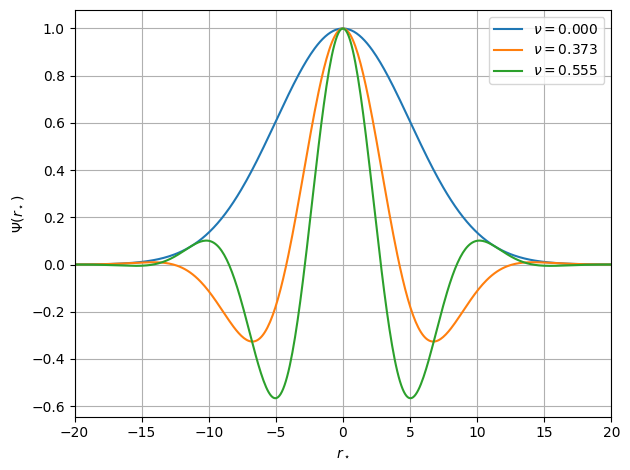

In [4]:
plt.figure()

for i, (s, nu) in enumerate(zip(signals, nus)):
    plt.plot(r, s, label=fr"$\nu={nu:.3f}$")

plt.xlim(-20, 20)
plt.xlabel(r"$r_\star$")
plt.ylabel(r"$\Psi(r_\star)$")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Spectral analysis

To understand the frequency content of the perturbation, we compute its Fourier transform.

Due to the oscillatory factor, we expect peaks centered around $\omega = \pm \nu$, modulated by the Fourier transform of the Gaussian envelope.

To improve frequency resolution, we employ zero-padding.

In [5]:
Npad = 8 * N

fft_vals = np.abs(
    np.fft.fftshift(
        np.fft.fft(signals, n=Npad, axis=1),
        axes=1
    )
)

# Normalize each spectrum
fft_vals /= fft_vals.max(axis=1, keepdims=True)

# Frequency axis
omega = 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(Npad, dr))

The Fourier transform of a Gaussian-modulated cosine consists of two symmetric peaks located at $\omega = \pm \nu$.

Their width is controlled by $\sigma$, reflecting the uncertainty relation between spatial localization and frequency spread.

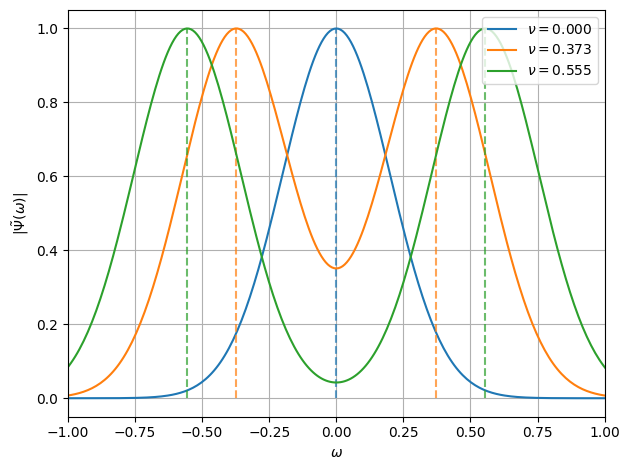

In [6]:
plt.figure()

for i, (f, nu) in enumerate(zip(fft_vals, nus)):
    line, = plt.plot(omega, f, label=fr"$\nu={nu:.3f}$")
    plt.vlines(0 if nu==0 else [-nu, nu], 0, 1,
               linestyles='--', alpha=0.7,
               colors=line.get_color())

plt.xlim(-1, 1)
plt.xlabel(r"$\omega$")
plt.ylabel(r"$|\tilde{\Psi}(\omega)|$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Spectral phase diagram

We introduce the dimensionless variables

$$
x \equiv \frac{\omega}{\nu},
\qquad
\alpha \equiv \sigma \nu .
$$

Remarkably, the spectral structure depends only on the combined parameter
$\alpha=\sigma\nu$, rather than on $\sigma$ and $\nu$ independently.

After normalization and rescaling, the Fourier spectrum can be written in the compact form

$$
\tilde{\Psi}(x,\alpha)
=
\exp\!\left[
-\frac{\alpha^2}{2}(x^2+1)
\right]
\cosh(\alpha^2 x).
$$

The hyperbolic cosine reflects the interference between the two symmetric Gaussian peaks centered at $\omega=\pm\nu$.

The heatmap below shows the evolution of the spectral profile as a function of the control parameter $\alpha$.

The dashed curves indicate the locations of the extrema of $\tilde{\Psi}(x,\alpha)$.
Below the critical line $\alpha=1$, the spectrum exhibits a single central maximum at $x=0$.
Above the transition, this point becomes a local minimum and two symmetric maxima emerge continuously at $\pm x_\star$.

The white contours represent iso-amplitude lines of the spectral profile.

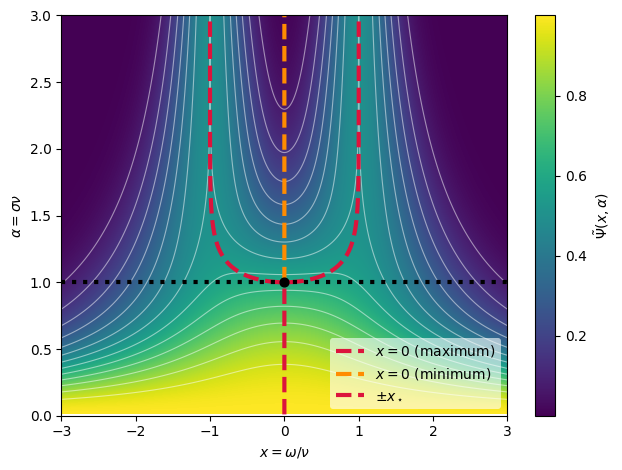

In [15]:
# -----------------------
# DIMENSIONLESS DOMAIN
# -----------------------
x = np.linspace(-3, 3, 5000)
alpha = np.linspace(0.01, 3, 5000)

X, Agrid = np.meshgrid(x, alpha)

# -----------------------
# DIMENSIONLESS SPECTRUM
# -----------------------
#
# Normalized spectral profile:
#
#   Ψ̃(x,α) =
#   exp[-α²(x²+1)/2] cosh(α²x)
#
# where:
#
#   x = ω/ν
#   α = σν
#
def spectrum(x, alpha):

    return np.exp(
        -0.5 * alpha**2 * (x**2 + 1)
    ) * np.cosh(alpha**2 * x)

Z = spectrum(X, Agrid)

# -----------------------
# EXTREMA CONDITION
# -----------------------
#
# The extrema satisfy
#
#   (x - 1) + (x + 1)e^{-2α²x} = 0
#
# yielding the non-trivial branches ±x*
#
def equation(x, alpha):

    return (
        (x - 1)
        + (x + 1) * np.exp(-2 * alpha**2 * x)
    )

xp = []
xm = []

for a in alpha:

    if a > 1:

        xp.append(
            fsolve(equation, 1.0, args=(a))[0]
        )

        xm.append(
            fsolve(equation, -1.0, args=(a))[0]
        )

    else:

        xp.append(np.nan)
        xm.append(np.nan)

xp = np.array(xp)
xm = np.array(xm)

mask = ~np.isnan(xp)

mask_left = alpha <= 1
mask_right = alpha > 1

plt.figure()

# -----------------------
# HEATMAP
# -----------------------
pcm = plt.imshow(
    Z,
    extent=[x.min(), x.max(), alpha.min(), alpha.max()],
    origin='lower',
    aspect='auto',
    interpolation='nearest',
    cmap='viridis'
)

cbar = plt.colorbar(pcm)
cbar.set_label(r'$\tilde{\Psi}(x,\alpha)$')

# -----------------------
# CONTOURS
# -----------------------
levels = np.linspace(Z.min(), Z.max(), 15)

plt.contour(
    X,
    Agrid,
    Z,
    levels=levels,
    colors='white',
    linewidths=0.8,
    alpha=0.5
)

# -----------------------
# CENTRAL BRANCH x = 0
# -----------------------
plt.plot(
    np.zeros_like(alpha[mask_left]),
    alpha[mask_left],
    color='crimson',
    linestyle='--',
    linewidth=3,
    label=r'$x=0$ (maximum)'
)

plt.plot(
    np.zeros_like(alpha[mask_right]),
    alpha[mask_right],
    color='darkorange',
    linestyle='--',
    linewidth=3,
    label=r'$x=0$ (minimum)'
)

# -----------------------
# NON-TRIVIAL BRANCHES
# -----------------------
plt.plot(
    xp[mask],
    alpha[mask],
    color='crimson',
    linestyle='--',
    linewidth=3,
    label=r'$\pm x_\star$'
)

plt.plot(
    xm[mask],
    alpha[mask],
    color='crimson',
    linestyle='--',
    linewidth=3
)

# -----------------------
# CRITICAL POINT
# -----------------------
plt.scatter(
    [0],
    [1],
    color='black',
    s=40,
    zorder=5
)

plt.axhline(
    1,
    color='black',
    linestyle=':',
    linewidth=3
)

# -----------------------
# LABELS
# -----------------------
plt.xlabel(r'$x=\omega/\nu$')
plt.ylabel(r'$\alpha=\sigma\nu$')

plt.xlim(-3, 3)
plt.ylim(0, 3)

plt.legend(
    frameon=True,
    framealpha=0.6,
    facecolor='white',
    edgecolor='none',
    loc='lower right'
)

plt.tight_layout()
plt.show()